In [3]:
import numpy as np
import random
import collections
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras import layers
keras.utils.set_random_seed(42)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

%matplotlib inline

# Loading text

In [4]:
path="alice in wonderland.txt"
with open(path,encoding="utf-8") as f:
    text=f.read().lower()
print(f"Text length: {len(text)}")
print()
print(text[0:1000])

Text length: 144016

chapter i.
down the rabbit-hole


alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought alice
“without pictures or conversations?”

so she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a white rabbit with pink eyes ran
close by her.

there was nothing so _very_ remarkable in that; nor did alice think it
so _very_ much out of the way to hear the rabbit say to itself, “oh
dear! oh dear! i shall be late!” (when she thought it over afterwards,
it occurred to her that she ought to have wondered at this, but at the
time it all seemed quite natural); but when the rabbit actually _took

# Encoding

## dictionary of chars and indexes

In [5]:
chars = sorted(list(set(text)))
print(f"Total chars: {len(chars)} \n")

# from char to numbers
char_indices = dict((c, i) for i, c in enumerate(chars))

# from numbers to chars
indices_chars = dict((i, c) for i, c in enumerate(chars))

print(f"char indexes: {char_indices}")
print(f"indexes chars: {indices_chars}")

Total chars: 47 

char indexes: {'\n': 0, ' ': 1, '!': 2, '(': 3, ')': 4, '*': 5, ',': 6, '-': 7, '.': 8, ':': 9, ';': 10, '?': 11, '[': 12, ']': 13, '_': 14, 'a': 15, 'b': 16, 'c': 17, 'd': 18, 'e': 19, 'f': 20, 'g': 21, 'h': 22, 'i': 23, 'j': 24, 'k': 25, 'l': 26, 'm': 27, 'n': 28, 'o': 29, 'p': 30, 'q': 31, 'r': 32, 's': 33, 't': 34, 'u': 35, 'v': 36, 'w': 37, 'x': 38, 'y': 39, 'z': 40, 'ù': 41, '—': 42, '‘': 43, '’': 44, '“': 45, '”': 46}
indexes chars: {0: '\n', 1: ' ', 2: '!', 3: '(', 4: ')', 5: '*', 6: ',', 7: '-', 8: '.', 9: ':', 10: ';', 11: '?', 12: '[', 13: ']', 14: '_', 15: 'a', 16: 'b', 17: 'c', 18: 'd', 19: 'e', 20: 'f', 21: 'g', 22: 'h', 23: 'i', 24: 'j', 25: 'k', 26: 'l', 27: 'm', 28: 'n', 29: 'o', 30: 'p', 31: 'q', 32: 'r', 33: 's', 34: 't', 35: 'u', 36: 'v', 37: 'w', 38: 'x', 39: 'y', 40: 'z', 41: 'ù', 42: '—', 43: '‘', 44: '’', 45: '“', 46: '”'}


## Data preparation

In [6]:
# used to say, i give you 30 character
# and you predict the next one, this is
# the label of the 30 chars sequence.
#
#          feature            | label
#--------------------------------
# nel mezzo del cammin di nos | t
maxlen = 40
step=2

sentences=[]
next_chars=[]

for i in range(0, len(text)-maxlen, step):
  sentences.append(text[i:i+maxlen])
  next_chars.append(text[i+maxlen])

sentences = np.array(sentences)
next_chars = np.array(next_chars)

print(f"Number of sentences: {len(sentences)}")
print("Sentence: ", sentences[89])
print("Next char: ", next_chars[89])

Number of sentences: 71988
Sentence:  ook her sister was reading, but it had n
Next char:  o


# Target distribution

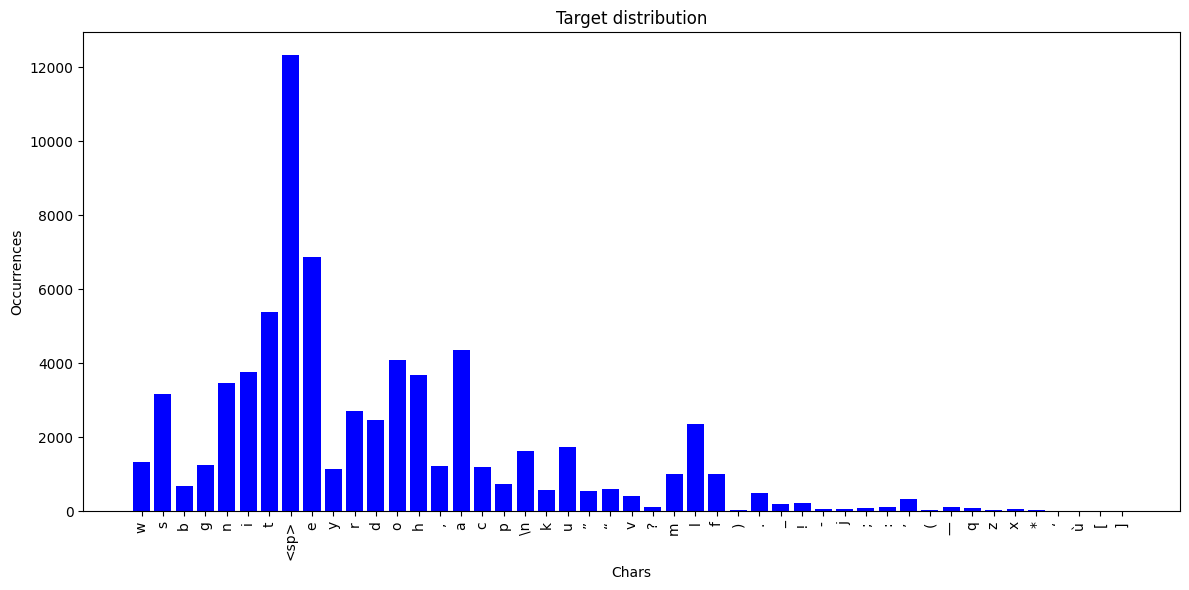

In [52]:
char_counts = collections.Counter(next_chars)

labels = list(char_counts.keys())
counts = list(char_counts.values())

for i in range(len(labels)):
    if labels[i] == '\n':
        labels[i] = r'\n'
    elif labels[i] == '\t':
        labels[i] = r'\t'
    elif labels[i] == ' ':
        labels[i] = '<sp>'

plt.figure(figsize=(12, 6))
plt.bar(labels, counts, color='blue')
plt.xticks(rotation=90)
plt.xlabel('Chars')
plt.ylabel('Occurrences')
plt.title('Target distribution')

plt.tight_layout()
plt.show()

## Train validation and test split

In [8]:
print("-------- Train Test split")

# definisco il numero di istanze nel training e test con la percentuale e creo
# la variabile di taglio
perc = 0.8
cut_test = int(perc * len(sentences))

# gap per evitare il dataleakage, dato che lo step è due posizioni potrebbero
# capitare nel test set frasi già presenti nel train (spiegare meglio nella
# relazione)

# definisco una variabile per evitare questo problema
skip = int(maxlen/step)

x_tr = sentences[: cut_test]
y_tr = next_chars[: cut_test]

x_test = sentences[cut_test+skip : len(sentences)]
y_test = next_chars[cut_test+skip : len(next_chars)]

print(f"x Train set dimension {x_tr.shape}")
print(f"x Test set dimension {x_test.shape}")
print()
print()
print("-------- Validation split")

# sfruttando sempre la stessa percentuale di split precedente vado a creare il
# validation set necessario.
val_cut = int(perc * len(x_tr))

x_train = x_tr[: val_cut]
y_train = y_tr[: val_cut]

x_val = x_tr[val_cut+skip : len(x_tr)]
y_val = y_tr[val_cut+skip : len(y_tr)]


print(f"x Train set dimension {x_train.shape}")
print(f"x validation set dimension {x_val.shape}")
print(f"x Test set dimension {x_test.shape}")

-------- Train Test split
x Train set dimension (57590,)
x Test set dimension (14378,)


-------- Validation split
x Train set dimension (46072,)
x validation set dimension (11498,)
x Test set dimension (14378,)


### one-hot encoding

In [9]:
print("-------- Encoding Data")

def one_hot_encode(x_dataset, y_dataset, maxlen, chars, char_indices):
    x_encoded = np.zeros((len(x_dataset), maxlen, len(chars)), dtype=np.float32)
    y_encoded = np.zeros((len(y_dataset), len(chars)), dtype=np.float32)

    for i, (sentence, next_char) in enumerate(zip(x_dataset, y_dataset)):
        for t, char in enumerate(sentence):
            x_encoded[i, t, char_indices[char]] = 1
        y_encoded[i, char_indices[next_char]] = 1

    return x_encoded, y_encoded

# encoding sui 3 set creati precedentemente
x_train, y_train = one_hot_encode(x_train, y_train, maxlen, chars, char_indices)
x_val, y_val = one_hot_encode(x_val, y_val, maxlen, chars, char_indices)
x_test, y_test = one_hot_encode(x_test, y_test, maxlen, chars, char_indices)

print(f"x train encoded dimension: {x_train.shape}")
print(f"y train encoded dimension: {y_train.shape}")
print()
print(f"x val encoded dimension: {x_val.shape}")
print(f"y val encoded dimension: {y_val.shape}")
print()
print(f"x test encoded dimension: {x_test.shape}")
print(f"y test encoded dimension: {y_test.shape}")

-------- Encoding Data
x train encoded dimension: (46072, 40, 47)
y train encoded dimension: (46072, 47)

x val encoded dimension: (11498, 40, 47)
y val encoded dimension: (11498, 47)

x test encoded dimension: (14378, 40, 47)
y test encoded dimension: (14378, 47)


# Useful functions

In [10]:
def plot_performance(history, model_name: str):

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))


    train_acc = history.history['accuracy']
    valid_acc = history.history['val_accuracy']
    train_loss = history.history['loss']
    valid_loss = history.history['val_loss']


    epochs = range(1, len(train_acc) + 1)

    # plot loss
    ax[0].plot(epochs, train_loss, 'b-', label='Training Loss')
    ax[0].plot(epochs, valid_loss, 'r--', label='Validation Loss')

    ax[0].set_title('Training & Validation Loss', fontsize=14)
    ax[0].set_xlabel('Epochs', fontsize=12)
    ax[0].set_ylabel('Loss', fontsize=12)
    ax[0].legend(loc='best')
    ax[0].grid(True, linestyle='--', alpha=0.6)

    # plot accuracy
    ax[1].plot(epochs, train_acc, 'b-', label='Training Accuracy')
    ax[1].plot(epochs, valid_acc, 'r--', label='Validation Accuracy')

    ax[1].set_title('Training & Validation Accuracy', fontsize=14)
    ax[1].set_xlabel('Epochs', fontsize=12)
    ax[1].set_ylabel('Accuracy', fontsize=12)
    ax[1].legend(loc='lower right')
    ax[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()

    name = model_name + 'performance.png'
    plt.savefig(name)
    plt.show()

# Convolutional model

## Callback

In [11]:
from keras.callbacks import LambdaCallback
import sys

def testAfterEpoch(epoch, _):
  if epoch < 10:
    return

  print()
  print()
  print(f"-------------- Generating text after {epoch}")

  start_index = random.randint(0, len(text)-maxlen-1)
  generated = ''

  sentence = text[start_index:start_index+maxlen]
  generated += sentence
  print("******** starting generation *********")
  print(sentence)
  print("**************************************")
  sys.stdout.write(generated)

  # 200 chars after our sentence
  for i in range(200):
    x_pred=np.zeros((1, maxlen, len(chars)))
    for t, char in enumerate(sentence):
      x_pred[0, t, char_indices[char]]=1
    preds=cnn_model.predict(x_pred, verbose=0)[0]
    next_index=np.argmax(preds)
    next_char=indices_chars[next_index]

    # delete first char and add the previous predicted
    # text is generated on the same line
    sentence=sentence[1:] + next_char
    sys.stdout.write(next_char)
    sys.stdout.flush()
  print()

cnn_print_callback = LambdaCallback(on_epoch_end=testAfterEpoch)

In [12]:
cnn_model = keras.Sequential(
    [
        keras.Input(shape=(x_train.shape[1], x_train.shape[2], 1)), # it's like a grayscale image (30x40x1)
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(len(chars), activation="softmax"),
    ]
)

cnn_model.compile(loss="categorical_crossentropy",
                  optimizer=keras.optimizers.RMSprop(learning_rate=0.01),
                  metrics=["accuracy"])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 45, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 10, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 47)             │       240,687 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,503 (1013.68 KB)

 Trainable params: 259,503 (1013.68 KB)

 Non-trainable params: 0 (0.00 B)

## model training

In [13]:
cnn_history=cnn_model.fit(x_train, y_train, batch_size=2048, epochs=30, validation_data=(x_val, y_val), callbacks=[cnn_print_callback])

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 334ms/step - accuracy: 0.0941 - loss: 3.8134 - val_accuracy: 0.1658 - val_loss: 3.1056
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.1767 - loss: 3.0630 - val_accuracy: 0.1658 - val_loss: 3.1310
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.1761 - loss: 3.0662 - val_accuracy: 0.1658 - val_loss: 3.1432
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.1766 - loss: 3.0650 - val_accuracy: 0.1658 - val_loss: 3.1575
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1767 - loss: 3.0647 - val_accuracy: 0.1658 - val_loss: 3.0956
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1751 - loss: 3.0444 - val_accuracy: 0.1658 - val_loss: 3.1600
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1770 - loss: 3.0575 - val_accuracy: 0.1658 - val_loss: 3.0893
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1763 - loss: 3.0279 - val_accuracy: 0.1661 -

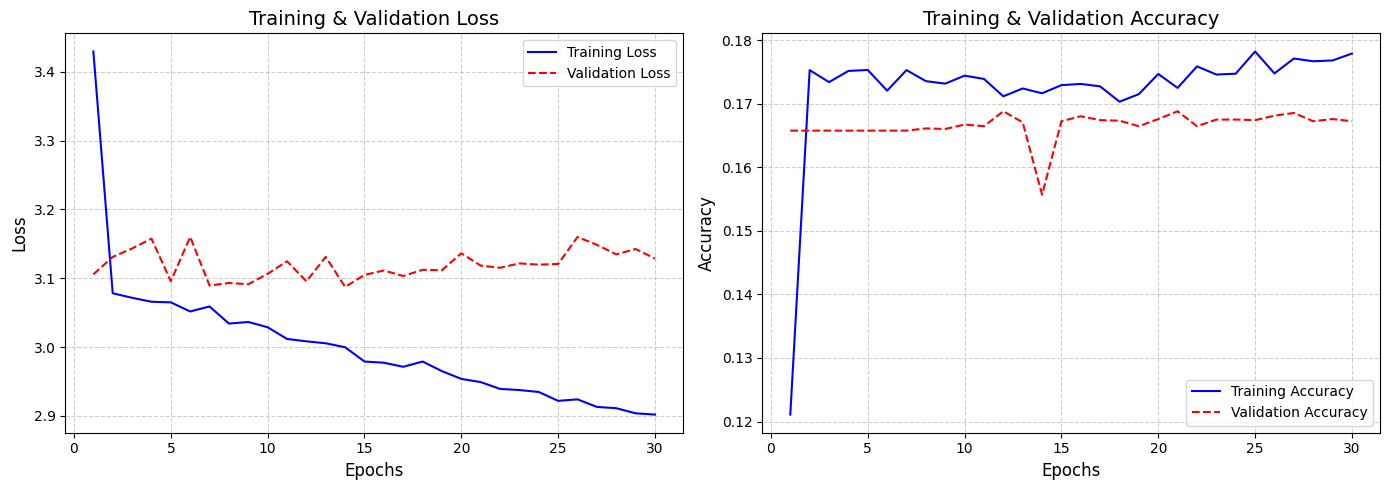

In [14]:
plot_performance(cnn_history, "Baseline model")

## model test

In [15]:
cnn_score = cnn_model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", cnn_score[0])
print("Test accuracy:", cnn_score[1])

Test loss: 3.1193418502807617
Test accuracy: 0.16754764318466187


# First LSTM model

## Callback

In [16]:
def testAfterEpoch(epoch, _):
  if epoch < 30:
    return

  print()
  print()
  print(f"-------------- Generating text after {epoch}")

  start_index = random.randint(0, len(text)-maxlen-1)
  generated = ''

  sentence = text[start_index:start_index+maxlen]
  generated += sentence
  print("******** starting generation *********")
  print(sentence)
  print("**************************************")
  sys.stdout.write(generated)

  # 200 chars after our sentence
  for i in range(200):
    x_pred=np.zeros((1, maxlen, len(chars)))
    for t, char in enumerate(sentence):
      x_pred[0, t, char_indices[char]]=1
    preds=lstm_model.predict(x_pred, verbose=0)[0]
    next_index=np.argmax(preds)
    next_char=indices_chars[next_index]

    # delete first char and add the previous predicted
    # text is generated on the same line
    sentence=sentence[1:] + next_char
    sys.stdout.write(next_char)
    sys.stdout.flush()
  print()

lstm_print_callback = LambdaCallback(on_epoch_end=testAfterEpoch)

In [47]:
lstm_model = keras.Sequential(
    [
                  keras.Input(shape=(x_train.shape[1], x_train.shape[2])),
                  layers.Conv1D(filters=128, kernel_size=3, activation='relu'),


                  layers.Dropout(0.3),
                  layers.LSTM(128, return_sequences=True),
                  layers.Dropout(0.4),
                  layers.LSTM(64),
                  layers.Dropout(0.4),
                  layers.Dense(len(chars), activation="softmax")
    ]
)

lstm_model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 38, 128)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 38, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 38, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 47)             │         3,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,223 (789.93 KB)

 Trainable params: 202,223 (789.93 KB)

 Non-trainable params: 0 (0.00 B)

## model training

In [48]:
es = keras.callbacks.EarlyStopping(monitor='val_loss', verbose=1, patience=3)
lstm_history = lstm_model.fit(x_train, y_train, batch_size=2048, epochs=100, validation_data=(x_val, y_val), callbacks=[lstm_print_callback, es])

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 90ms/step - accuracy: 0.1284 - loss: 3.3525 - val_accuracy: 0.1658 - val_loss: 3.0655
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1858 - loss: 2.9867 - val_accuracy: 0.2942 - val_loss: 2.6509
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.2779 - loss: 2.6460 - val_accuracy: 0.3118 - val_loss: 2.4461
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.3023 - loss: 2.4755 - val_accuracy: 0.3513 - val_loss: 2.2904
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.3321 - loss: 2.3556 - val_accuracy: 0.3802 - val_loss: 2.1860
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.3526 - loss: 2.2742 - val_accuracy: 0.3947 - val_loss: 2.1231
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3697 - loss: 2.2151 - val_accuracy: 0.4100 - val_loss: 2.0699
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3834 - loss: 2.1610 - val_accuracy: 0.

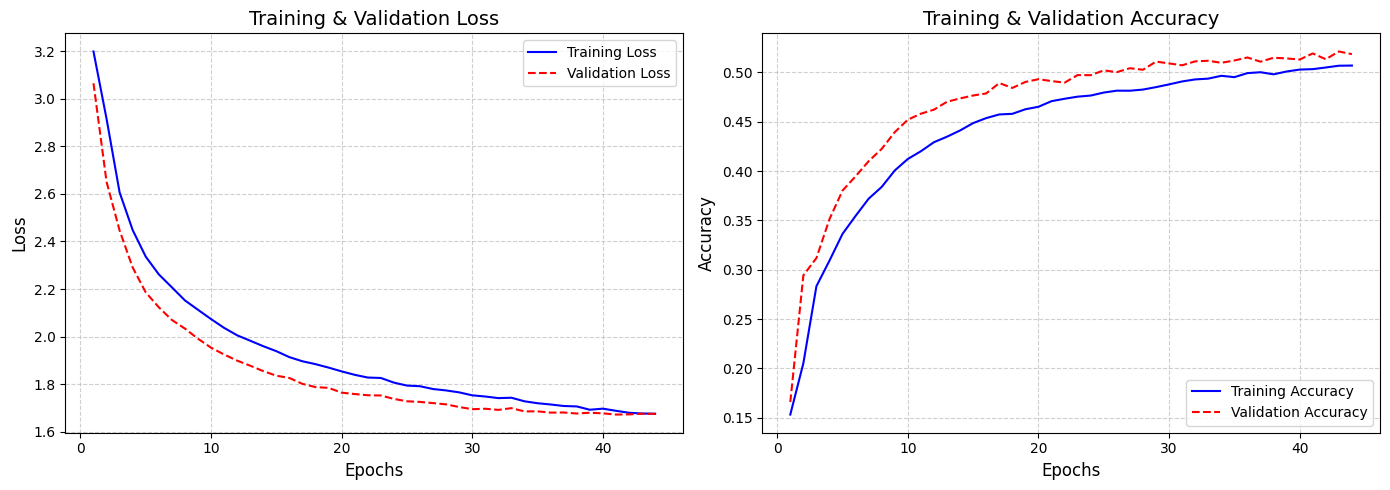

In [49]:
plot_performance(lstm_history, "LSTM model")

## model test

In [50]:
lstm_score = lstm_model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", lstm_score[0])
print("Test accuracy:", lstm_score[1])

Test loss: 1.6792638301849365
Test accuracy: 0.5175963044166565


# Model comparison

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Macro-AUC calculated on 45/47 classes in Test set.
Macro-AUC calculated on 45/47 classes in Test set.


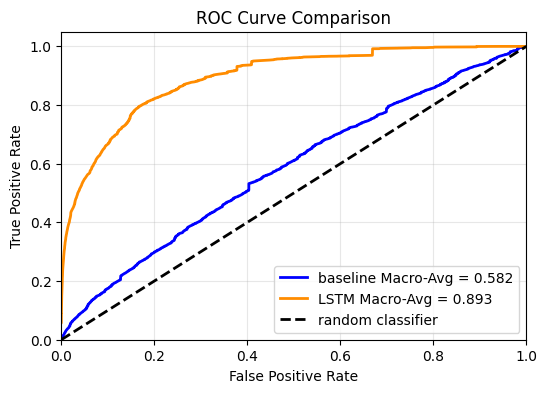

In [51]:
def get_macro_roc(y_true, y_pred, n_classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # nel test set potrebbero non essere presenti tutti i caratteri dato che le
    # classi sono molto sbilanciate, nel calcolo della curva ROC viene preso
    # in considerazione questo problema.
    valid_classes = []

    for i in range(n_classes):
        # permette di saltare il carattere se non presente nel test set
        if np.sum(y_true[:, i]) == 0:
            continue

        # se è presente calcolata la ROC
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        valid_classes.append(i)

    # nessuna classe valida
    if not valid_classes:
        return None, None, None

    # calcolo fpr
    all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))

    # calcolo tpr
    mean_tpr = np.zeros_like(all_fpr)
    for i in valid_classes:
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    # calcolo tpr medio sfruttando solamente le classi presenti nel test set
    mean_tpr /= len(valid_classes)


    macro_auc = auc(all_fpr, mean_tpr)

    print(f"Macro-AUC calculated on {len(valid_classes)}/{n_classes} classes in Test set.")

    return all_fpr, mean_tpr, macro_auc

# predizioni di ciascun modello
y_pred_cnn = cnn_model.predict(x_test)
y_pred_lstm = lstm_model.predict(x_test)

n_classes = y_test.shape[1]

# calcolo roc
fpr_cnn_macro, tpr_cnn_macro, auc_cnn_macro = get_macro_roc(y_test, y_pred_cnn, n_classes)
fpr_lstm_macro, tpr_lstm_macro, auc_lstm_macro = get_macro_roc(y_test, y_pred_lstm, n_classes)

# plot
plt.figure(figsize=(6, 4))

# cnn
if auc_cnn_macro is not None:
    plt.plot(fpr_cnn_macro, tpr_cnn_macro,
             label=f'baseline Macro-Avg = {auc_cnn_macro:.3f}',
             color='blue', linestyle='-', linewidth=2)

# LSTM
if auc_lstm_macro is not None:
    plt.plot(fpr_lstm_macro, tpr_lstm_macro,
             label=f'LSTM Macro-Avg = {auc_lstm_macro:.3f}',
             color='darkorange', linestyle='-', linewidth=2)

# random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='random classifier')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.savefig("ROC_Macro_Robust.png")
plt.show()